# Full EDA Graphs
## Assembly Report, Clustering, Slippage, and Mol_Type Analysis

This notebook produces EDA visualizations answering:
1. How many GFF files have slippage?
2. How many species have slippage?
3. Median # of assemblies per species
4. Influenza A proportion for subsetting
5. Positive slippage inclusion analysis
6. DNA vs RNA slippage comparison
7. Genome length distribution
8. GC content distribution
9. Assemblies per species histogram/boxplot (log scale)
10. Slippage location analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 6)})

## 1. Load Data

In [2]:
assembly = pd.read_csv("../assembly_data_report.csv")
slippage = pd.read_csv("../gff_results/gff_parsed.csv")
mol_type = pd.read_csv("../gff_results/mol_type_parsed.csv")
cluster = pd.read_csv("../clustering_results/clusterRes_cluster.tsv", sep='\t', names=["cluster", "ID"])
cluster = cluster.drop_duplicates(['cluster', 'ID'])

print(f"assembly:  {assembly.shape}")
print(f"slippage:  {slippage.shape}")
print(f"mol_type:  {mol_type.shape}")
print(f"cluster:   {cluster.shape}")

assembly:  (272515, 9)
slippage:  (251146, 9)
mol_type:  (1326715, 3)
cluster:   (1326596, 2)


### 1a. Extract accession from slippage source_file & create merged dataframes

In [3]:
# Extract GCA accession from source_file path
slippage["accession"] = slippage["source_file"].str.extract(r'(GCA_\d+\.\d+)')

# --- mol_type_cluster: merge mol_type with cluster on record_id == ID ---
mol_type_cluster = mol_type.merge(cluster, left_on="record_id", right_on="ID", how="inner").drop(columns = "ID")
print(f"mol_type_cluster: {mol_type_cluster.shape}")
mol_type_cluster.head()

mol_type_cluster: (1326711, 4)


,record_id,accession,mol_type,cluster
0,AB000403.1,GCA_000847645.1,genomic RNA,AB000403.1
1,AB000404.1,GCA_000847645.1,genomic RNA,AB000404.1
2,AB000851.1,GCA_000871205.1,genomic RNA,NC_009896.1
3,AB000923.1,GCA_000840045.1,genomic DNA,AB000923.1
4,AB000924.1,GCA_000840045.1,genomic DNA,AB000924.1


In [4]:
# --- full_merge: assembly + mol_type (one mol_type per accession) ---
# Collapse mol_type to one row per accession (take first mol_type)
mol_type_per_accession = mol_type.groupby("accession")["mol_type"].first().reset_index()

assembly_mol = assembly.merge(mol_type_per_accession, on="accession", how="left")
print(f"assembly_mol: {assembly_mol.shape}")
assembly_mol.head()

assembly_mol: (272515, 10)


,accession,assembly_level,assembly_name,submitter,total_sequence_length,gc_percent,taxid,organism_name,release_date,mol_type
0,GCA_000320725.1,Contig,APLentillevirus_1.0,CNRS UMR IRD 6236,1193433,28.0,1077221,Acanthamoeba polyphaga lentillevirus,2012-07-27,genomic DNA
1,GCA_000847085.1,Complete Genome,ViralProj14573,"M. Jaeger, Dept of Virology, University of Ulm...",4491,33.5,1977403,Acholeplasma phage MV-L51,1993-04-21,NaN
2,GCA_000848265.1,Complete Genome,ViralProj14654,"NIH, NLM",5894,55.0,11788,Abelson murine leukemia virus,1998-01-22,genomic RNA
3,GCA_000850225.1,Complete Genome,ViralProj14710,"BMC, University of Latvia",4268,44.0,154784,Acinetobacter phage AP205,2003-01-30,NaN
4,GCA_000858405.1,Complete Genome,ViralProj15222,NaN,5234,40.0,185639,Acheta domestica densovirus,2002-02-04,NaN


In [5]:
# --- slippage_assembly: merge slippage with assembly info ---
slippage_assembly = slippage.merge(assembly, on="accession", how="left")

# Also add mol_type info
slippage_full = slippage_assembly.merge(mol_type_per_accession, on="accession", how="left")
print(f"slippage_full: {slippage_full.shape}")
slippage_full.head()

slippage_full: (251146, 19)


,Unnamed: 0,record_id,type,start,end,strand,qualifiers,search_term,source_file,accession,assembly_level,assembly_name,submitter,total_sequence_length,gc_percent,taxid,organism_name,release_date,mol_type
0,0,MG982796.1,CDS,24,594,1,"{'ID': ['cds-AVT55874.1'], 'Parent': ['gene-PA...",slip,../viral_data_all/ncbi_dataset/data_subset/GCA...,GCA_038807845.1,Complete Genome,ASM3880784v1,NIAID Centers of Excellence for Influenza Rese...,13629.0,43.5,11320.0,Influenza A virus,2018-04-03,viral cRNA
1,1,MG982796.1,CDS,595,724,1,"{'ID': ['cds-AVT55874.1'], 'Parent': ['gene-PA...",slip,../viral_data_all/ncbi_dataset/data_subset/GCA...,GCA_038807845.1,Complete Genome,ASM3880784v1,NIAID Centers of Excellence for Influenza Rese...,13629.0,43.5,11320.0,Influenza A virus,2018-04-03,viral cRNA
2,2,MT090511.1,CDS,0,570,1,"{'ID': ['cds-QIC52522.1'], 'Parent': ['gene-PA...",slip,../viral_data_all/ncbi_dataset/data_subset/GCA...,GCA_039170005.1,Complete Genome,ASM3917000v1,NIAID Centers of Excellence for Influenza Rese...,13288.0,44.5,11320.0,Influenza A virus,2020-02-20,viral cRNA
3,3,MT090511.1,CDS,571,760,1,"{'ID': ['cds-QIC52522.1'], 'Parent': ['gene-PA...",slip,../viral_data_all/ncbi_dataset/data_subset/GCA...,GCA_039170005.1,Complete Genome,ASM3917000v1,NIAID Centers of Excellence for Influenza Rese...,13288.0,44.5,11320.0,Influenza A virus,2020-02-20,viral cRNA
4,4,MK624178.1,CDS,12,582,1,"{'ID': ['cds-QBL91539.1'], 'Parent': ['gene-PA...",slip,../viral_data_all/ncbi_dataset/data_subset/GCA...,GCA_039109635.1,Complete Genome,ASM3910963v1,2009 H1N1 Flu Outbreak Sequencing Centers,13426.0,43.0,11320.0,Influenza A virus,2019-03-13,viral cRNA


In [7]:
# Create a DNA/RNA category column from mol_type
def classify_nucleic_acid(mol):
    if pd.isna(mol):
        return "Unknown"
    mol_lower = mol.lower()
    if "dna" in mol_lower:
        return "DNA"
    elif "rna" in mol_lower or "crna" in mol_lower:
        return "RNA"
    else:
        return "Other"

assembly_mol["nucleic_acid"] = assembly_mol["mol_type"].apply(classify_nucleic_acid)
slippage_full["nucleic_acid"] = slippage_full["mol_type"].apply(classify_nucleic_acid)

print("assembly_mol nucleic_acid value counts:")
print(assembly_mol["nucleic_acid"].value_counts())
print("\nslippage_full nucleic_acid value counts:")
print(slippage_full["nucleic_acid"].value_counts())

assembly_mol nucleic_acid value counts:
nucleic_acid
RNA        168307
Unknown     61219
DNA         42989
Name: count, dtype: int64

slippage_full nucleic_acid value counts:
nucleic_acid
RNA        240053
DNA          7900
Unknown      3193
Name: count, dtype: int64


---
## 2. How many GFF files have slippage?

In [8]:
n_gff_with_slippage = slippage["source_file"].nunique()
n_accessions_with_slippage = slippage["accession"].nunique()
n_total_assemblies = assembly["accession"].nunique()

print(f"GFF files (source_file) with slippage: {n_gff_with_slippage}")
print(f"Unique accessions with slippage:       {n_accessions_with_slippage}")
print(f"Total assemblies:                      {n_total_assemblies}")
print(f"Fraction with slippage:                {n_accessions_with_slippage / n_total_assemblies:.4f}")

GFF files (source_file) with slippage: 125146
Unique accessions with slippage:       123585
Total assemblies:                      272515
Fraction with slippage:                0.4535


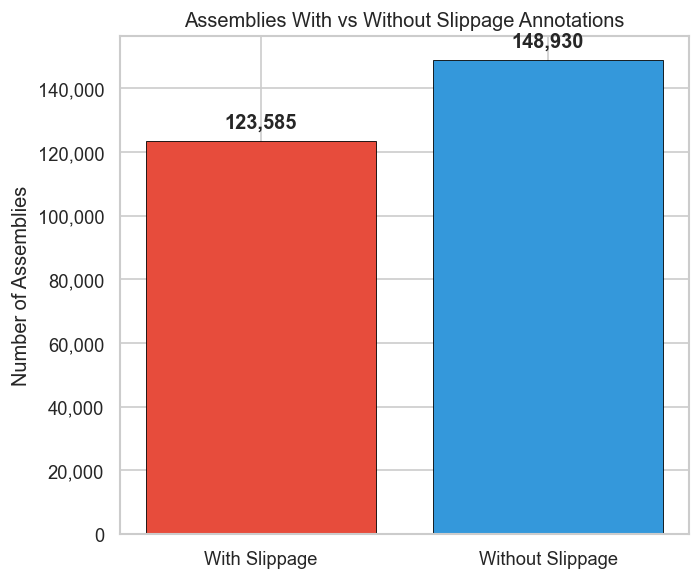

In [9]:
# Bar chart: assemblies with vs without slippage
fig, ax = plt.subplots(figsize=(6, 5))
labels = ["With Slippage", "Without Slippage"]
counts = [n_accessions_with_slippage, n_total_assemblies - n_accessions_with_slippage]
colors = ["#e74c3c", "#3498db"]
bars = ax.bar(labels, counts, color=colors, edgecolor="black", linewidth=0.5)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + n_total_assemblies * 0.01,
            f"{c:,}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Number of Assemblies")
ax.set_title("Assemblies With vs Without Slippage Annotations")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

---
## 3. How many species have slippage?

In [10]:
# Map accessions with slippage to organism_name via assembly
accessions_with_slip = slippage["accession"].dropna().unique()
species_with_slip = assembly[assembly["accession"].isin(accessions_with_slip)]["organism_name"].nunique()
total_species = assembly["organism_name"].nunique()

print(f"Species (organism_name) with slippage: {species_with_slip}")
print(f"Total species:                         {total_species}")
print(f"Fraction of species with slippage:     {species_with_slip / total_species:.4f}")

Species (organism_name) with slippage: 26924
Total species:                         88872
Fraction of species with slippage:     0.3030


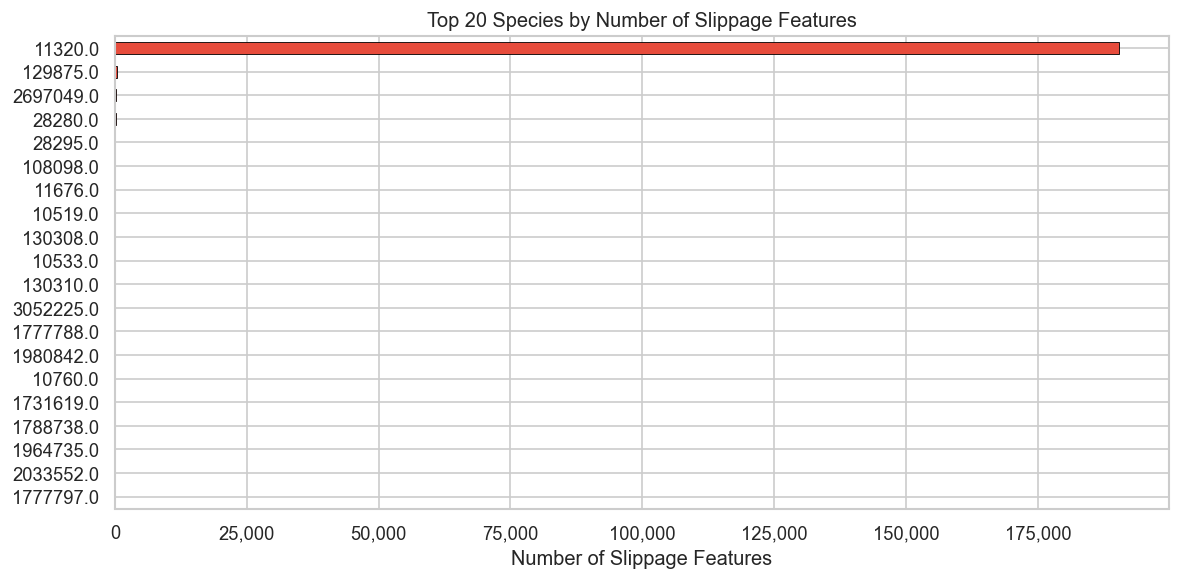

In [ ]:
# Top 20 species by number of slippage features
slip_species_counts = (
    slippage_full
    .dropna(subset=["organism_name"])
    .groupby("organism_name")
    .size()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 5))
slip_species_counts.plot.barh(ax=ax, color="#e74c3c", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Number of Slippage Features")
ax.set_ylabel("")
ax.set_title("Top 20 Species by Number of Slippage Features")
ax.invert_yaxis()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

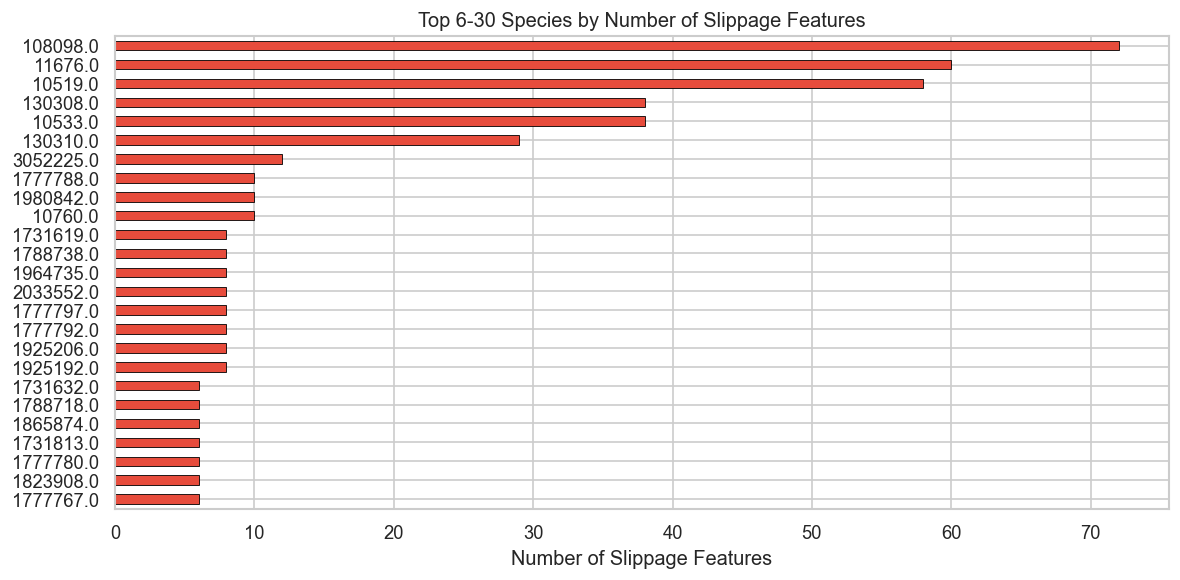

In [20]:
# Top 6-30 species by number of slippage features, EXCLUDING TOP 5
slip_species_counts = (
    slippage_full
    .dropna(subset=["taxid"])
    .groupby("taxid")
    .size()
    .sort_values(ascending=False)
    .iloc[5:30]
)

fig, ax = plt.subplots(figsize=(10, 5))
slip_species_counts.plot.barh(ax=ax, color="#e74c3c", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Number of Slippage Features")
ax.set_ylabel("")
ax.set_title("Top 6-30 Species by Number of Slippage Features")
ax.invert_yaxis()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

---
## 4. Median number of assemblies per species

In [12]:
assemblies_per_species = assembly.groupby("organism_name")["accession"].nunique()

print(f"Median assemblies per species:  {assemblies_per_species.median()}")
print(f"Mean assemblies per species:    {assemblies_per_species.mean():.2f}")
print(f"Max assemblies per species:     {assemblies_per_species.max()}")
print(f"Min assemblies per species:     {assemblies_per_species.min()}")
print(f"\nDescriptive stats:\n{assemblies_per_species.describe()}")

Median assemblies per species:  1.0
Mean assemblies per species:    3.07
Max assemblies per species:     96282
Min assemblies per species:     1

Descriptive stats:
count    88872.000000
mean         3.066376
std        330.330611
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max      96282.000000
Name: accession, dtype: float64


In [13]:
# Top 20 species by number of assemblies
top_species = assemblies_per_species.sort_values(ascending=False).head(20)
print("Top 20 species by assembly count:")
print(top_species.to_string())

Top 20 species by assembly count:
organism_name
Influenza A virus                                  96282
Severe acute respiratory syndrome coronavirus 2    12449
Influenza B virus                                  11983
Siphoviridae environmental samples                  7135
Monkeypox virus                                     6961
uncultured Caudovirales phage                       3243
Porcine circovirus 2                                2406
Microviridae sp.                                    1768
Rotavirus A                                         1422
Bacteriophage sp.                                   1349
Myoviridae environmental samples                     872
uncultured podovirus                                 796
Human rotavirus A                                    761
uncultured virus                                     695
West Nile virus                                      633
Microvirus sp.                                       623
Circular genetic element sp.            

---
## 5. Influenza A proportion analysis (subsetting)

In [14]:
# Identify Influenza A assemblies
is_influenza_a = assembly["organism_name"].str.contains("Influenza A", case=False, na=False)
n_influenza_a = is_influenza_a.sum()
n_other = len(assembly) - n_influenza_a

print(f"Influenza A assemblies: {n_influenza_a:,}")
print(f"Other assemblies:       {n_other:,}")
print(f"Influenza A fraction:   {n_influenza_a / len(assembly):.4f}")
print(f"\nRatio Influenza A : Other = 1 : {n_other / n_influenza_a:.1f}" if n_influenza_a > 0 else "No Influenza A found")

Influenza A assemblies: 137,043
Other assemblies:       135,472
Influenza A fraction:   0.5029

Ratio Influenza A : Other = 1 : 1.0


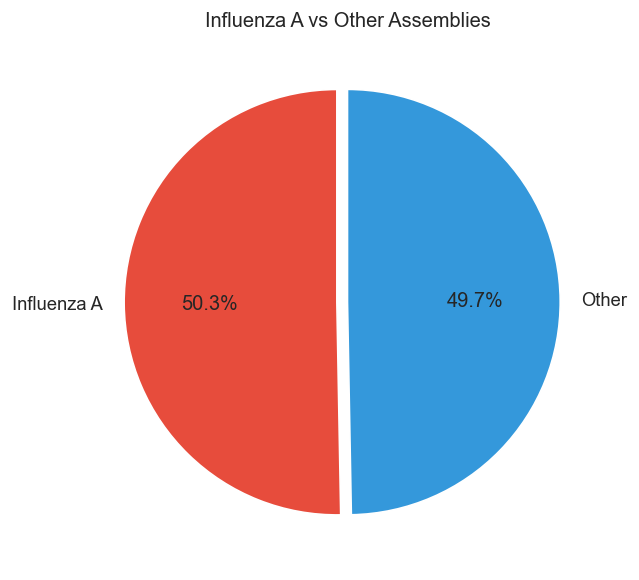

In [34]:
# --- Graph 1: Pie chart ---
fig, ax = plt.subplots(figsize=(6, 5))
ax.pie([n_influenza_a, n_other],
       labels=["Influenza A", "Other"],
       autopct="%1.1f%%",
       colors=["#e74c3c", "#3498db"],
       startangle=90, explode=(0.05, 0))
ax.set_title("Influenza A vs Other Assemblies")
plt.tight_layout()
plt.show()

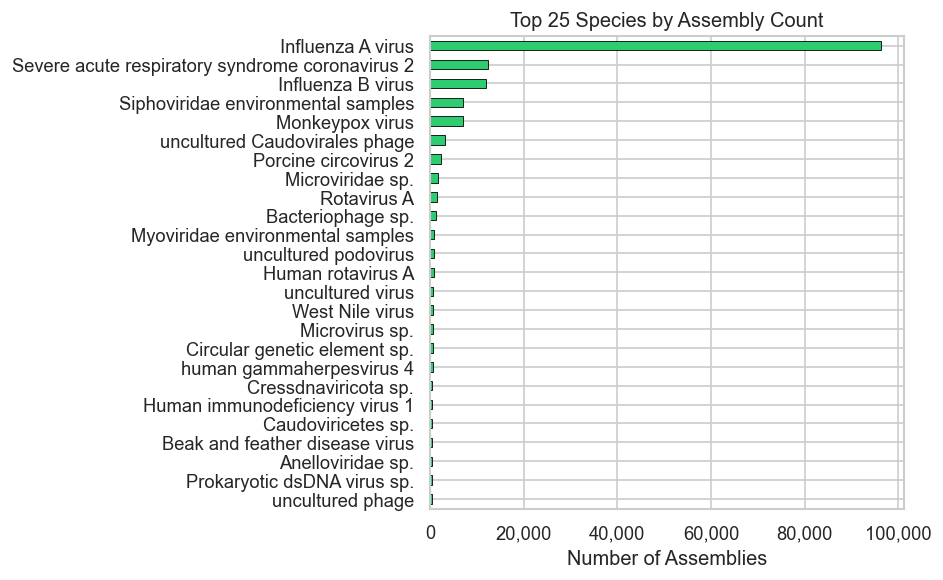

In [40]:
# --- Graph 2: Horizontal bar chart ---
fig, ax = plt.subplots(figsize=(8, 5))
top10 = assemblies_per_species.sort_values(ascending=False).head(25)
top10.sort_values().plot.barh(ax=ax, color="#2ecc71", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Number of Assemblies")
ax.set_ylabel("")
ax.set_title("Top 25 Species by Assembly Count")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

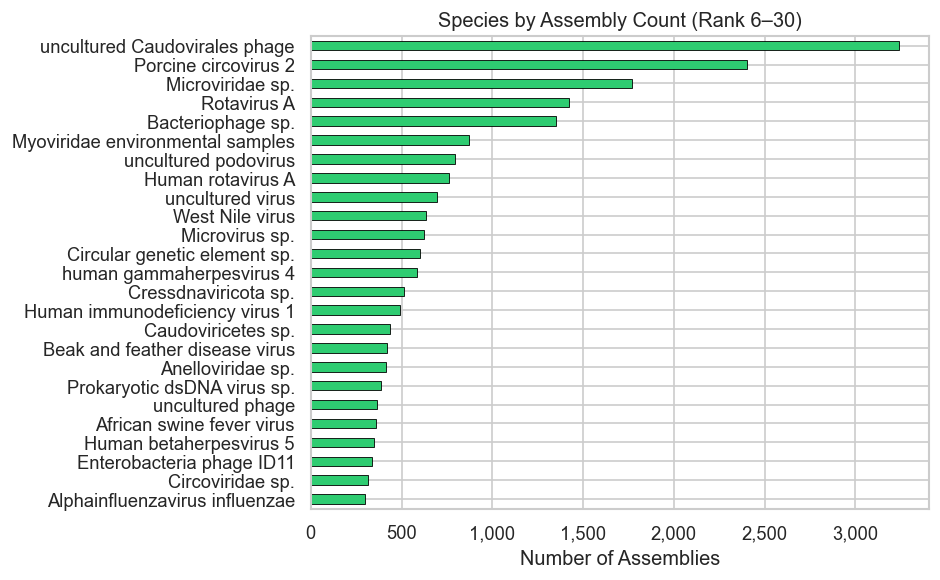

In [41]:

# --- Graph 3: Horizontal bar chart (excluding top 5) ---
fig, ax = plt.subplots(figsize=(8, 5))
top_sorted = assemblies_per_species.sort_values(ascending=False).iloc[5:30]
top_sorted.sort_values().plot.barh(ax=ax, color="#2ecc71", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Number of Assemblies")
ax.set_ylabel("")
ax.set_title("Species by Assembly Count (Rank 6–30)")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

In [42]:
# Influenza A slippage analysis
influenza_a_accessions = assembly[is_influenza_a]["accession"]
slip_in_influenza = slippage[slippage["accession"].isin(influenza_a_accessions)]
slip_not_influenza = slippage[~slippage["accession"].isin(influenza_a_accessions)]

print(f"Slippage features in Influenza A:     {len(slip_in_influenza):,}")
print(f"Slippage features in non-Influenza A: {len(slip_not_influenza):,}")
print(f"Influenza A fraction of slippage:     {len(slip_in_influenza) / len(slippage):.4f}")

Slippage features in Influenza A:     239,105
Slippage features in non-Influenza A: 12,041
Influenza A fraction of slippage:     0.9521


---
## 6. Positive slippage analysis

In [12]:
slippage

,Unnamed: 0,record_id,type,start,end,strand,qualifiers,search_term,source_file,accession
0,0,MG982796.1,CDS,24,594,1,"{'ID': ['cds-AVT55874.1'], 'Parent': ['gene-PA...",slip,../viral_data_all/ncbi_dataset/data_subset/GCA...,GCA_038807845.1
1,1,MG982796.1,CDS,595,724,1,"{'ID': ['cds-AVT55874.1'], 'Parent': ['gene-PA...",slip,../viral_data_all/ncbi_dataset/data_subset/GCA...,GCA_038807845.1
2,2,MT090511.1,CDS,0,570,1,"{'ID': ['cds-QIC52522.1'], 'Parent': ['gene-PA...",slip,../viral_data_all/ncbi_dataset/data_subset/GCA...,GCA_039170005.1
3,3,MT090511.1,CDS,571,760,1,"{'ID': ['cds-QIC52522.1'], 'Parent': ['gene-PA...",slip,../viral_data_all/ncbi_dataset/data_subset/GCA...,GCA_039170005.1
4,4,MK624178.1,CDS,12,582,1,"{'ID': ['cds-QBL91539.1'], 'Parent': ['gene-PA...",slip,../viral_data_all/ncbi_dataset/data_subset/GCA...,GCA_039109635.1
...,...,...,...,...,...,...,...,...,...,...
251141,251231,PQ011362.1,CDS,571,760,1,"{'ID': ['cds-XCO67773.1'], 'Parent': ['gene-PA...",slip,../viral_data_all/ncbi_dataset/data_subset/GCA...,GCA_040780665.1
251142,251232,AJ302647.1,CDS,843,2151,1,"{'ID': ['cds-CAC38421.2'], 'Parent': ['gene-ga...",slip,../viral_data_all/ncbi_dataset/data_subset/GCA...,GCA_003108965.1
251143,251233,AJ302647.1,CDS,2150,5180,1,"{'ID': ['cds-CAC38421.2'], 'Parent': ['gene-ga...",slip,../viral_data_all/ncbi_dataset/data_subset/GCA...,GCA_003108965.1
251144,251234,AJ302646.1,CDS,843,2151,1,"{'ID': ['cds-CAC38430.2'], 'Parent': ['gene-ga...",slip,../viral_data_all/ncbi_dataset/data_subset/GCA...,GCA_003108945.1


In [17]:
# Check the search_term and qualifiers for slippage direction info
print("Search terms in slippage data:")
print(slippage["search_term"].value_counts())
print(f"\nStrand distribution:")
print(slippage["strand"].value_counts())

Search terms in slippage data:
search_term
slip    251146
Name: count, dtype: int64

Strand distribution:
strand
 1    250552
-1       594
Name: count, dtype: int64


In [18]:
# Check if qualifiers contain ribosomal slippage direction
# Parse a sample of qualifiers to check for +1 / -1 slippage
import ast

def extract_exception(q):
    """Extract the 'exception' field from qualifiers string."""
    try:
        d = ast.literal_eval(q)
        return d.get("exception", [None])[0]
    except:
        return None

slippage["exception_type"] = slippage["qualifiers"].apply(extract_exception)
print("Exception types in slippage features:")
print(slippage["exception_type"].value_counts())

Exception types in slippage features:
exception_type
ribosomal slippage                        250032
Ribosomal Slippage                           867
transcriptional_slippage                       4
ribosomal slippage, ribosomal slippage         2
Name: count, dtype: int64


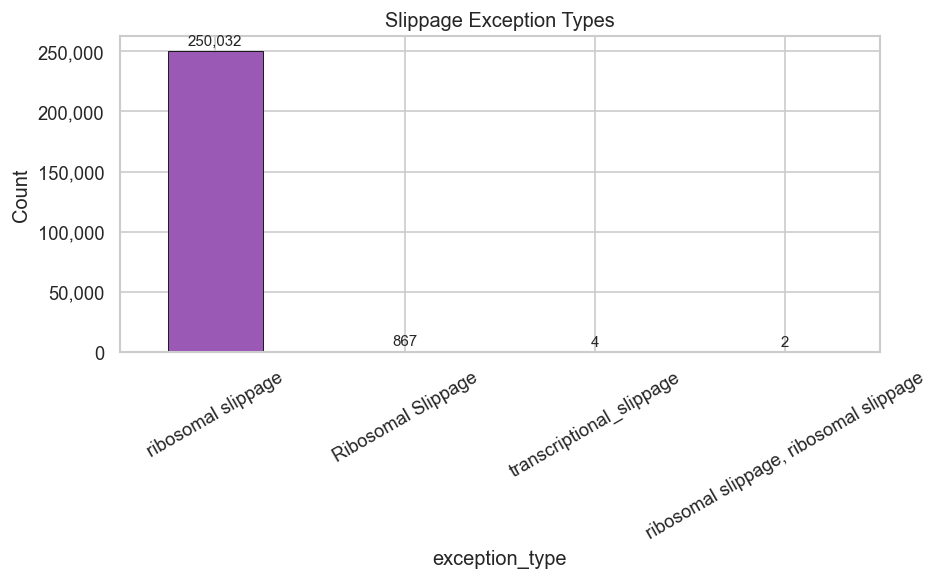

In [19]:
# Bar chart of exception types
exception_counts = slippage["exception_type"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
exception_counts.plot.bar(ax=ax, color="#9b59b6", edgecolor="black", linewidth=0.5)
ax.set_ylabel("Count")
ax.set_title("Slippage Exception Types")
ax.tick_params(axis="x", rotation=30)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for i, (idx, val) in enumerate(exception_counts.items()):
    ax.text(i, val + exception_counts.max() * 0.01, f"{val:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

---
## 7. DNA vs RNA: Is slippage more common in RNA?

In [24]:
# Overall mol_type distribution
print("Mol_type distribution (unique per accession):")
print(assembly_mol["mol_type"].value_counts())
print(f"\nSlippage features by nucleic acid type:")
print(slippage_full["mol_type"].value_counts())

Mol_type distribution (unique per accession):
mol_type
viral cRNA     155050
genomic DNA     42987
genomic RNA     13203
mRNA               52
other RNA           2
other DNA           2
Name: count, dtype: int64

Slippage features by nucleic acid type:
mol_type
viral cRNA     239149
genomic DNA      7900
genomic RNA       904
Name: count, dtype: int64


In [25]:
# Rate of slippage per nucleic acid type
assembly_mol["has_slippage"] = assembly_mol["accession"].isin(accessions_with_slip)

slippage_rate = (
    assembly_mol.groupby("mol_type")["has_slippage"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "with_slippage", "count": "total"})
)
slippage_rate["rate"] = slippage_rate["with_slippage"] / slippage_rate["total"]
print("Slippage rate by nucleic acid type:")
print(slippage_rate)

Slippage rate by nucleic acid type:
             with_slippage   total      rate
mol_type                                    
genomic DNA           3569   42987  0.083025
genomic RNA            441   13203  0.033401
mRNA                     0      52  0.000000
other DNA                0       2  0.000000
other RNA                0       2  0.000000
viral cRNA          119575  155050  0.771203


In [ ]:
is_influenza_a = assembly_mol["organism_name"].str.contains("Influenza A", case=False, na=False)
assembly_mol_temp = assembly_mol[is_influenza_a]

KeyError: 'has_slippage'

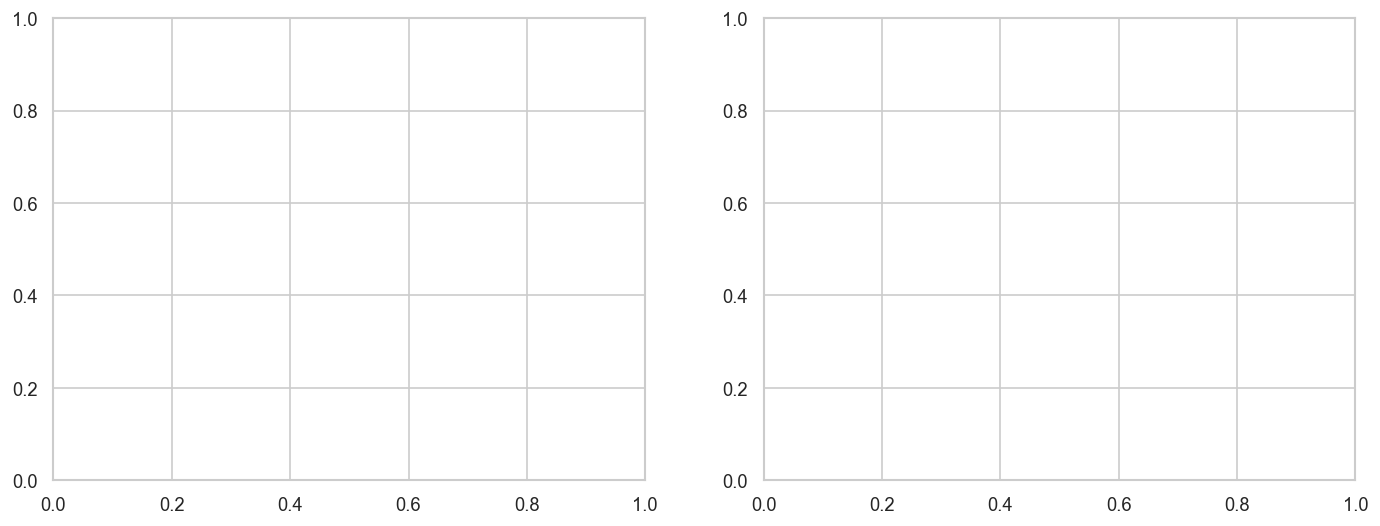

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Count of assemblies by mol_type (with/without slippage)
slip_by_na = assembly_mol_temp.groupby(["mol_type", "has_slippage"]).size().unstack(fill_value=0)
slip_by_na.columns = ["No Slippage", "Has Slippage"]
slip_by_na.plot.bar(ax=axes[0], stacked=True, color=["#3498db", "#e74c3c"],
                     edgecolor="black", linewidth=0.5)
axes[0].set_ylabel("Number of Assemblies")
axes[0].set_title("Assemblies by mol_type & Slippage")
axes[0].tick_params(axis="x", rotation=0)
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].legend(loc="upper right")

# Right: Slippage rate by nucleic acid type
slippage_rate["rate"].plot.bar(ax=axes[1], color=["#2ecc71", "#e67e22", "#9b59b6", "#1abc9c"],
                                edgecolor="black", linewidth=0.5)
axes[1].set_ylabel("Fraction with Slippage")
axes[1].set_title("Slippage Rate by mol_type")
axes[1].tick_params(axis="x", rotation=0)
for i, (idx, row) in enumerate(slippage_rate.iterrows()):
    axes[1].text(i, row["rate"] + 0.005, f"{row['rate']:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

---
## 8. Genome length distribution

In [28]:
print("Genome length (total_sequence_length) summary:")
print(assembly["total_sequence_length"].describe())

Genome length (total_sequence_length) summary:
count    2.725150e+05
mean     3.401432e+04
std      2.205301e+06
min      1.200000e+01
25%      1.313300e+04
50%      1.342600e+04
75%      2.349400e+04
max      1.150678e+09
Name: total_sequence_length, dtype: float64


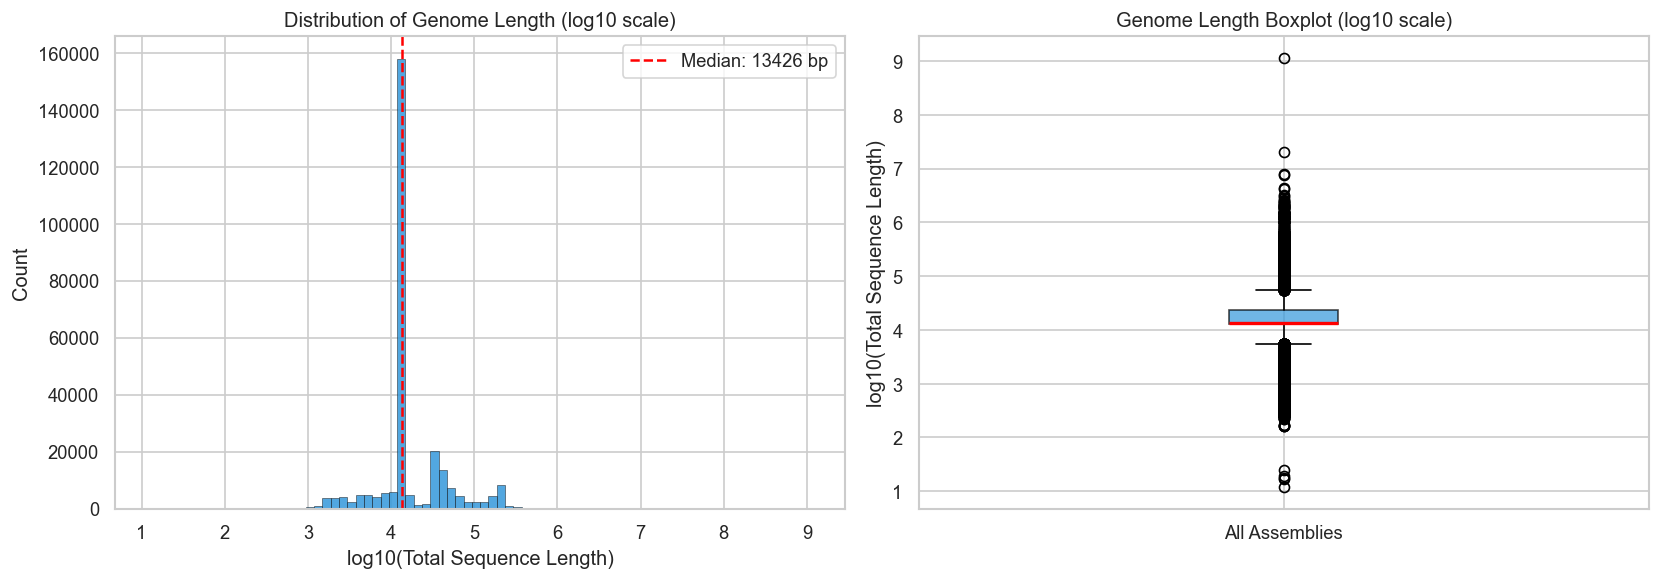

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (log scale on x-axis)
log_lengths = np.log10(assembly["total_sequence_length"].clip(lower=1))
axes[0].hist(log_lengths, bins=80, color="#3498db", edgecolor="black", linewidth=0.3, alpha=0.85)
axes[0].set_xlabel("log10(Total Sequence Length)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Genome Length (log10 scale)")
axes[0].axvline(log_lengths.median(), color="red", linestyle="--", label=f"Median: {10**log_lengths.median():.0f} bp")
axes[0].legend()

# Boxplot
axes[1].boxplot(log_lengths, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#3498db", alpha=0.7),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_ylabel("log10(Total Sequence Length)")
axes[1].set_title("Genome Length Boxplot (log10 scale)")
axes[1].set_xticklabels(["All Assemblies"])

plt.tight_layout()
plt.show()

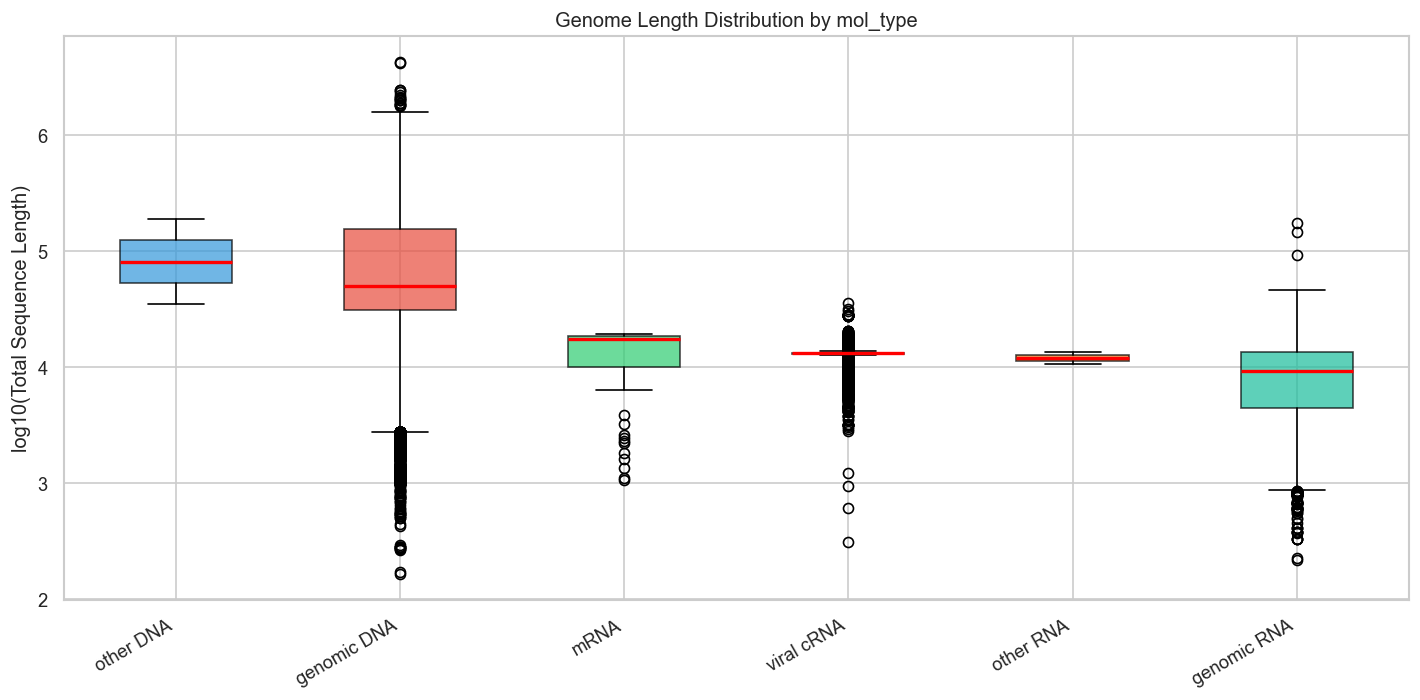

In [44]:
# Genome length by mol_type
fig, ax = plt.subplots(figsize=(12, 6))

mol_types = assembly_mol["mol_type"].dropna().unique()
# Sort by median genome length for readability
medians = {mt: np.log10(assembly_mol[assembly_mol["mol_type"] == mt]["total_sequence_length"].clip(lower=1)).median()
            for mt in mol_types}
mol_types_sorted = sorted(mol_types, key=lambda x: medians[x], reverse=True)

data_by_mt = [np.log10(assembly_mol[assembly_mol["mol_type"] == mt]["total_sequence_length"].clip(lower=1))
              for mt in mol_types_sorted]
# Filter out empty groups
data_labels = [(d, mt) for d, mt in zip(data_by_mt, mol_types_sorted) if len(d) > 0]

bp = ax.boxplot([d for d, l in data_labels], vert=True, patch_artist=True,
                medianprops=dict(color="red", linewidth=2))
colors_mt = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6", "#e67e22", "#1abc9c"]
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(colors_mt[i % len(colors_mt)])
    patch.set_alpha(0.7)
ax.set_xticklabels([l for d, l in data_labels], rotation=30, ha="right")
ax.set_ylabel("log10(Total Sequence Length)")
ax.set_title("Genome Length Distribution by mol_type")
plt.tight_layout()
plt.show()


---
## 9. GC Content Distribution

In [45]:
print("GC percent summary:")
print(assembly["gc_percent"].describe())

GC percent summary:
count    272515.000000
mean         43.628850
std           6.185211
min          18.000000
25%          41.000000
50%          43.000000
75%          44.500000
max          78.500000
Name: gc_percent, dtype: float64


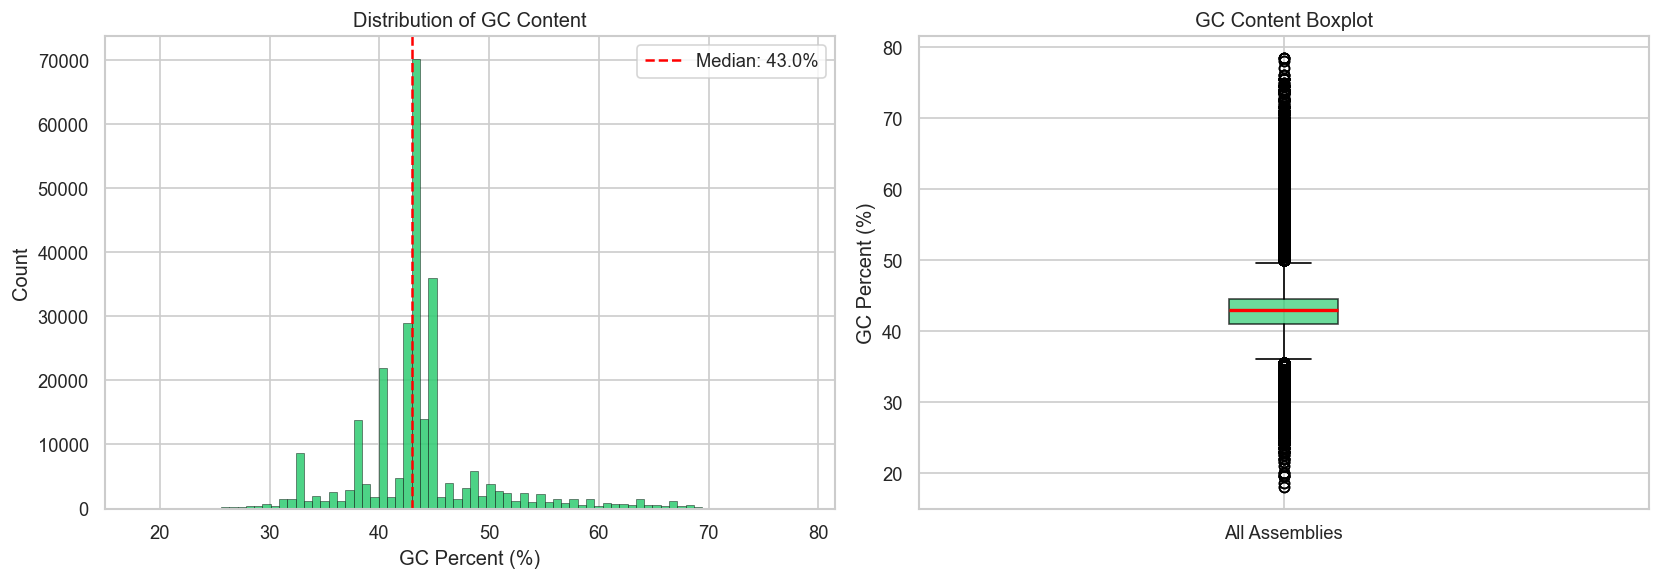

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
gc = assembly["gc_percent"].dropna()
axes[0].hist(gc, bins=80, color="#2ecc71", edgecolor="black", linewidth=0.3, alpha=0.85)
axes[0].set_xlabel("GC Percent (%)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of GC Content")
axes[0].axvline(gc.median(), color="red", linestyle="--", label=f"Median: {gc.median():.1f}%")
axes[0].legend()

# Boxplot
axes[1].boxplot(gc, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#2ecc71", alpha=0.7),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_ylabel("GC Percent (%)")
axes[1].set_title("GC Content Boxplot")
axes[1].set_xticklabels(["All Assemblies"])

plt.tight_layout()
plt.show()

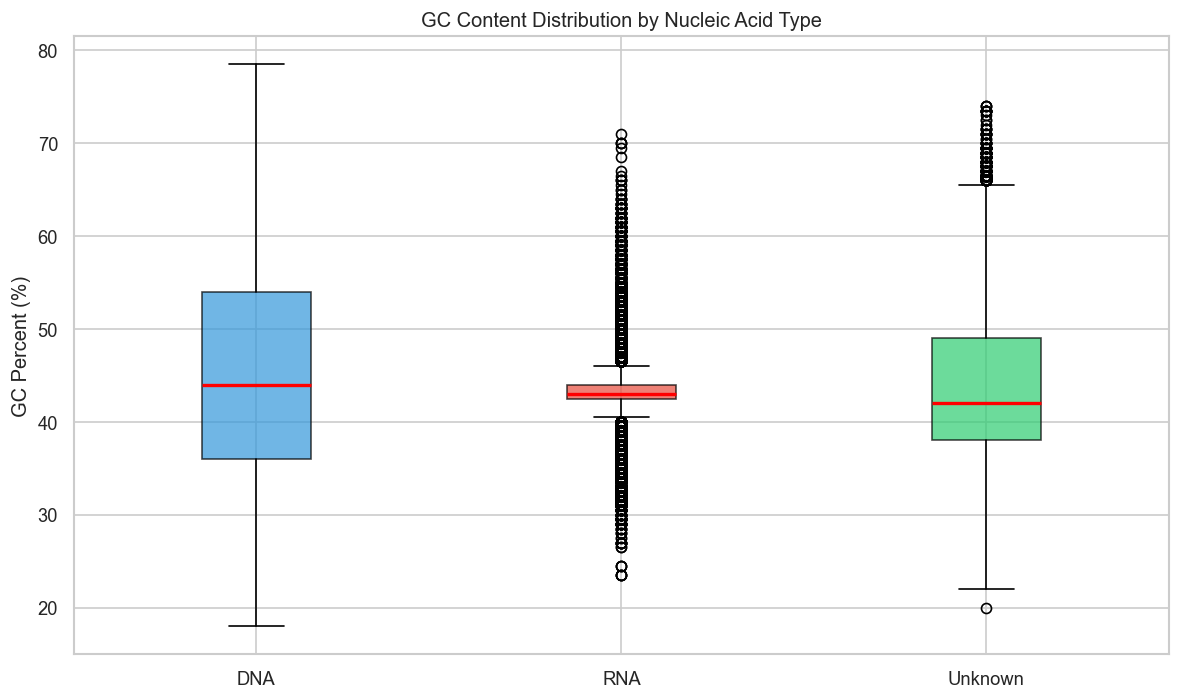

In [47]:
# GC content by nucleic acid type
fig, ax = plt.subplots(figsize=(10, 6))
gc_by_na = [assembly_mol[assembly_mol["nucleic_acid"] == na]["gc_percent"].dropna()
            for na in ["DNA", "RNA", "Other", "Unknown"]]
gc_labels = ["DNA", "RNA", "Other", "Unknown"]
gc_data_labels = [(d, l) for d, l in zip(gc_by_na, gc_labels) if len(d) > 0]
bp = ax.boxplot([d for d, l in gc_data_labels], vert=True, patch_artist=True,
                medianprops=dict(color="red", linewidth=2))
colors_gc = ["#3498db", "#e74c3c", "#2ecc71", "#95a5a6"]
for patch, c in zip(bp["boxes"], colors_gc):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax.set_xticklabels([l for d, l in gc_data_labels])
ax.set_ylabel("GC Percent (%)")
ax.set_title("GC Content Distribution by Nucleic Acid Type")
plt.tight_layout()
plt.show()

---
## 10. Assemblies per species — Histogram & Boxplot (log scale)

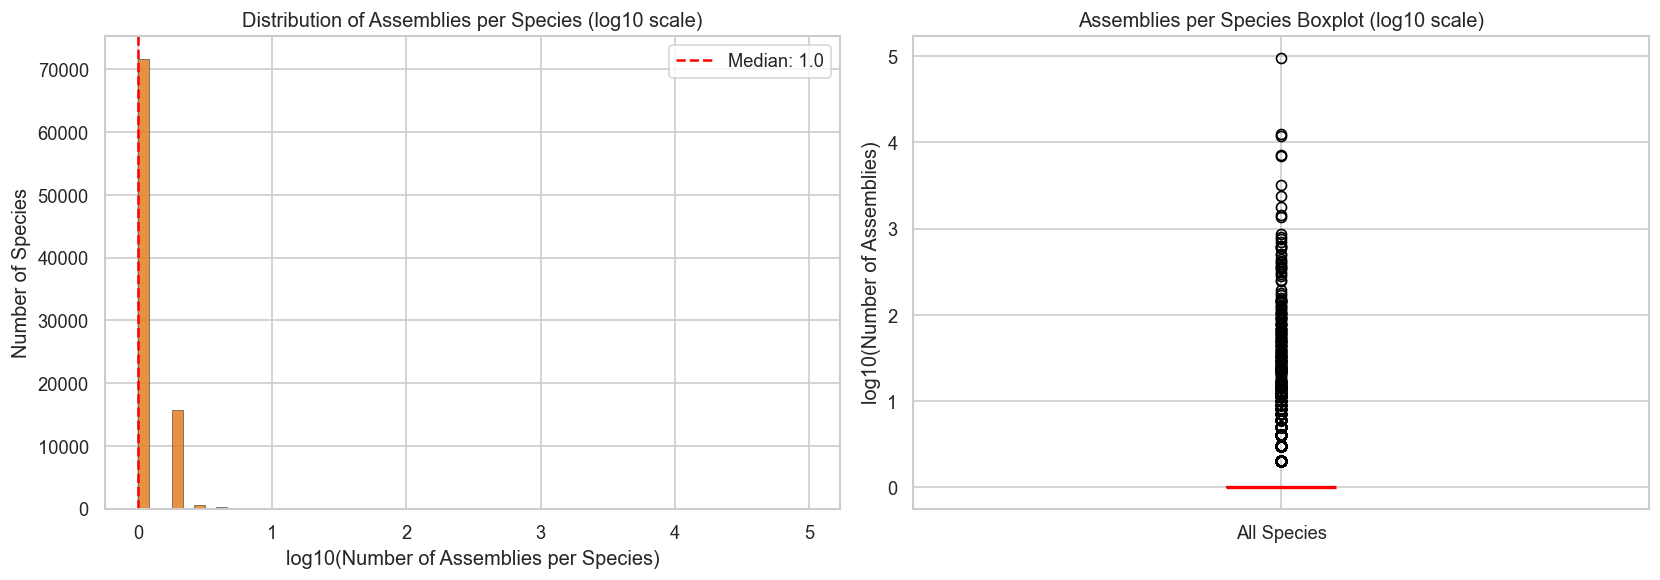

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

log_aps = np.log10(assemblies_per_species.clip(lower=1))

# Histogram (log scale)
axes[0].hist(log_aps, bins=60, color="#e67e22", edgecolor="black", linewidth=0.3, alpha=0.85)
axes[0].set_xlabel("log10(Number of Assemblies per Species)")
axes[0].set_ylabel("Number of Species")
axes[0].set_title("Distribution of Assemblies per Species (log10 scale)")
axes[0].axvline(log_aps.median(), color="red", linestyle="--",
                label=f"Median: {10**log_aps.median():.1f}")
axes[0].legend()

# Boxplot (log scale)
axes[1].boxplot(log_aps, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#e67e22", alpha=0.7),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_ylabel("log10(Number of Assemblies)")
axes[1].set_title("Assemblies per Species Boxplot (log10 scale)")
axes[1].set_xticklabels(["All Species"])

plt.tight_layout()
plt.show()

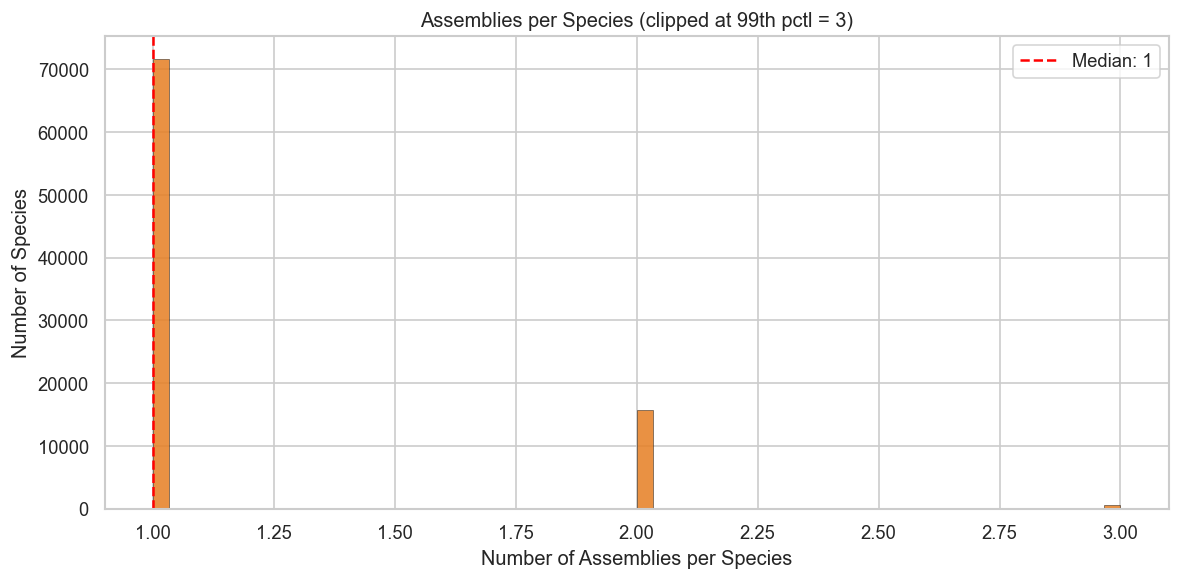

In [49]:
# Also show raw (non-log) histogram for comparison, clipping extreme outliers
fig, ax = plt.subplots(figsize=(10, 5))
threshold = assemblies_per_species.quantile(0.99)
clipped = assemblies_per_species[assemblies_per_species <= threshold]
ax.hist(clipped, bins=60, color="#e67e22", edgecolor="black", linewidth=0.3, alpha=0.85)
ax.set_xlabel("Number of Assemblies per Species")
ax.set_ylabel("Number of Species")
ax.set_title(f"Assemblies per Species (clipped at 99th pctl = {threshold:.0f})")
ax.axvline(assemblies_per_species.median(), color="red", linestyle="--",
           label=f"Median: {assemblies_per_species.median():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

---
## 11. Location of slippage — position, count, & % of full sequence length

In [ ]:
slippage_full

In [7]:
# Add slippage length and relative position columns
slippage_full["slip_length"] = slippage_full["end"] - slippage_full["start"]
slippage_full["slip_midpoint"] = (slippage_full["start"] + slippage_full["end"]) / 2
slippage_full["slip_start_pct"] = slippage_full["start"] / slippage_full["total_sequence_length"] * 100
slippage_full["slip_mid_pct"] = slippage_full["slip_midpoint"] / slippage_full["total_sequence_length"] * 100
slippage_full["slip_length_pct"] = slippage_full["slip_length"] / slippage_full["total_sequence_length"] * 100

print(f"Slippage features with assembly info: {slippage_full.dropna(subset=['total_sequence_length']).shape[0]:,}")
print(f"\nSlippage start % of genome:")
print(slippage_full["slip_start_pct"].describe())
print(f"\nSlippage length % of genome:")
print(slippage_full["slip_length_pct"].describe())

Slippage features with assembly info: 247,953

Slippage start % of genome:
count    247953.000000
mean          3.102466
std           5.972791
min           0.000000
25%           0.075081
50%           4.296464
75%           4.346833
max          98.676746
Name: slip_start_pct, dtype: float64

Slippage length % of genome:
count    247953.000000
mean          2.864594
std           2.713618
min           0.001669
25%           1.407612
50%           1.445065
75%           4.262001
max          72.589641
Name: slip_length_pct, dtype: float64


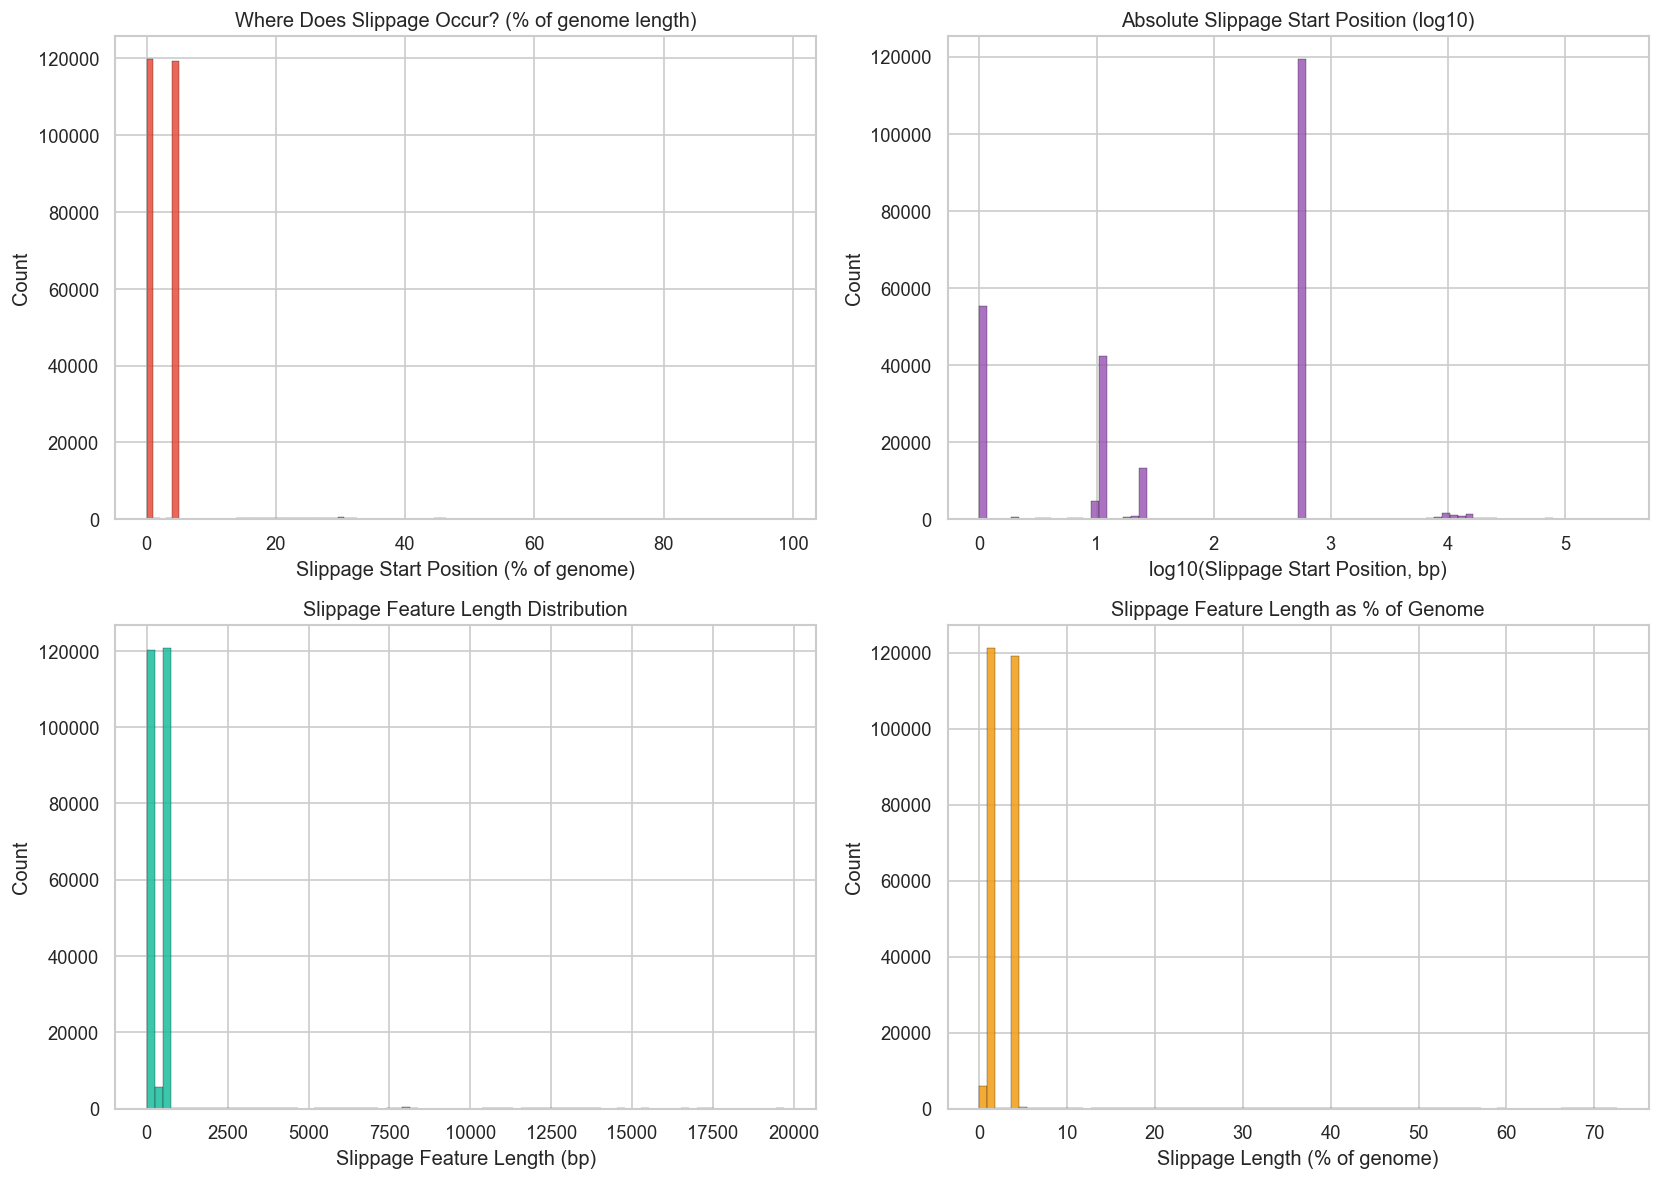

In [8]:
# Where does slippage occur along the genome (as % of total length)?
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

valid = slippage_full.dropna(subset=["slip_start_pct", "total_sequence_length"])

# 1. Histogram of slippage start position (% of genome)
axes[0, 0].hist(valid["slip_start_pct"].clip(0, 100), bins=100,
                color="#e74c3c", edgecolor="black", linewidth=0.2, alpha=0.85)
axes[0, 0].set_xlabel("Slippage Start Position (% of genome)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Where Does Slippage Occur? (% of genome length)")

# 2. Histogram of absolute slippage start position
log_start = np.log10(valid["start"].clip(lower=1))
axes[0, 1].hist(log_start, bins=80, color="#9b59b6", edgecolor="black", linewidth=0.2, alpha=0.85)
axes[0, 1].set_xlabel("log10(Slippage Start Position, bp)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Absolute Slippage Start Position (log10)")

# 3. Slippage feature length distribution
axes[1, 0].hist(valid["slip_length"].clip(lower=0), bins=80,
                color="#1abc9c", edgecolor="black", linewidth=0.2, alpha=0.85)
axes[1, 0].set_xlabel("Slippage Feature Length (bp)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Slippage Feature Length Distribution")

# 4. Slippage length as % of genome
axes[1, 1].hist(valid["slip_length_pct"].clip(0, 100), bins=80,
                color="#f39c12", edgecolor="black", linewidth=0.2, alpha=0.85)
axes[1, 1].set_xlabel("Slippage Length (% of genome)")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Slippage Feature Length as % of Genome")

plt.tight_layout()
plt.show()

Slippage features per accession:
count    123585.000000
mean          2.006336
std           0.278973
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max          19.000000
Name: n_slip_features, dtype: float64


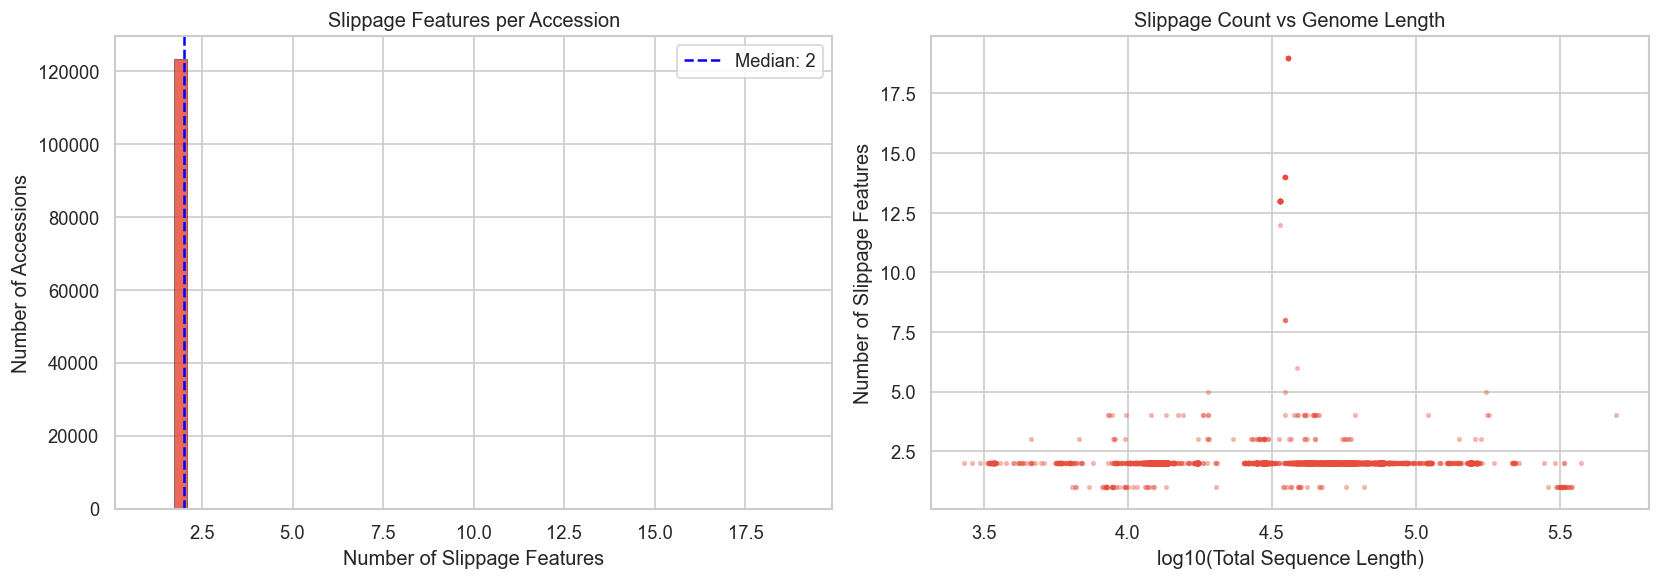

In [11]:
# Number of slippage features per accession
slip_count_per_accession = slippage.groupby("accession").size().reset_index(name="n_slip_features")

print(f"Slippage features per accession:")
print(slip_count_per_accession["n_slip_features"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(slip_count_per_accession["n_slip_features"], bins=50,
             color="#e74c3c", edgecolor="black", linewidth=0.3, alpha=0.85)
axes[0].set_xlabel("Number of Slippage Features")
axes[0].set_ylabel("Number of Accessions")
axes[0].set_title("Slippage Features per Accession")
axes[0].axvline(slip_count_per_accession["n_slip_features"].median(), color="blue",
                linestyle="--", label=f"Median: {slip_count_per_accession['n_slip_features'].median():.0f}")
axes[0].legend()

# Scatter: slippage count vs genome length
slip_with_length = slip_count_per_accession.merge(assembly[["accession", "total_sequence_length"]], on="accession")
axes[1].scatter(np.log10(slip_with_length["total_sequence_length"].clip(lower=1)),
                slip_with_length["n_slip_features"],
                alpha=0.3, s=5, c="#e74c3c")
axes[1].set_xlabel("log10(Total Sequence Length)")
axes[1].set_ylabel("Number of Slippage Features")
axes[1].set_title("Slippage Count vs Genome Length")

plt.tight_layout()
plt.show()

KeyError: ['nucleic_acid']

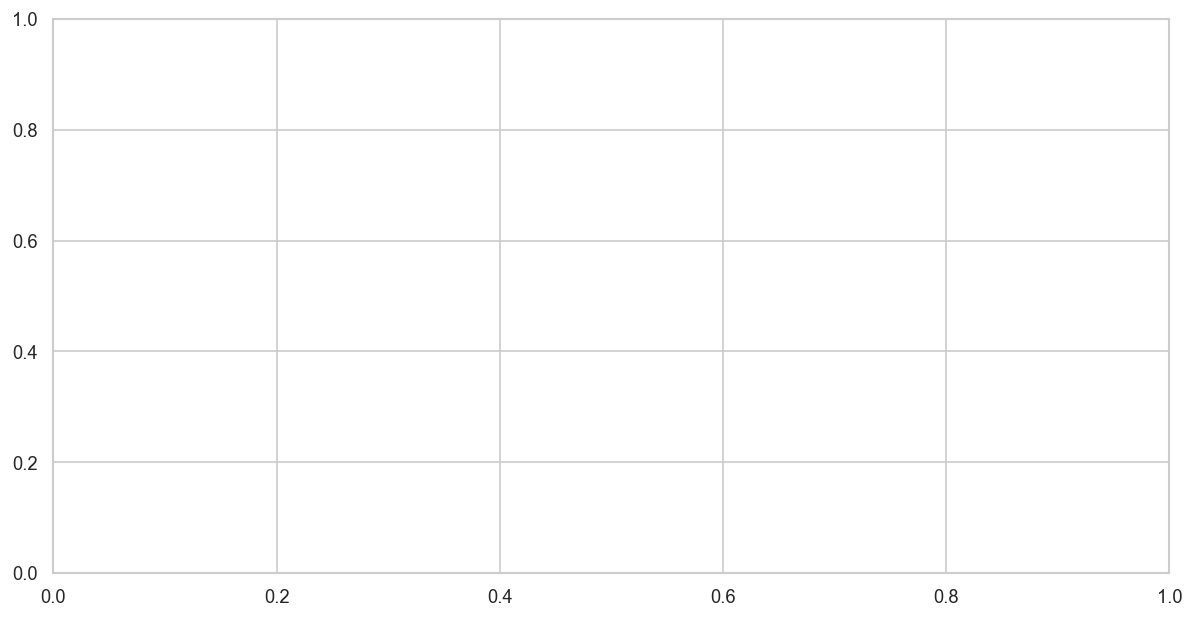

In [10]:
# Scatter plot: slippage position (% genome) vs genome length, colored by nucleic acid
fig, ax = plt.subplots(figsize=(12, 6))

valid_na = slippage_full.dropna(subset=["slip_start_pct", "total_sequence_length", "nucleic_acid"])
colors_map = {"DNA": "#3498db", "RNA": "#e74c3c", "Other": "#2ecc71", "Unknown": "#95a5a6"}

for na_type, color in colors_map.items():
    subset = valid_na[valid_na["nucleic_acid"] == na_type]
    if len(subset) > 0:
        ax.scatter(np.log10(subset["total_sequence_length"].clip(lower=1)),
                   subset["slip_start_pct"].clip(0, 100),
                   alpha=0.15, s=5, c=color, label=f"{na_type} (n={len(subset):,})")

ax.set_xlabel("log10(Total Sequence Length)")
ax.set_ylabel("Slippage Start Position (% of genome)")
ax.set_title("Slippage Location vs Genome Length by Nucleic Acid Type")
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

---
## Summary Statistics

In [ ]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Total assemblies:                  {n_total_assemblies:,}")
print(f"Total species:                     {total_species:,}")
print(f"GFF files with slippage:           {n_gff_with_slippage:,}")
print(f"Accessions with slippage:          {n_accessions_with_slippage:,} ({n_accessions_with_slippage/n_total_assemblies*100:.1f}%)")
print(f"Species with slippage:             {species_with_slip:,} ({species_with_slip/total_species*100:.1f}%)")
print(f"Median assemblies per species:     {assemblies_per_species.median():.0f}")
print(f"Influenza A assemblies:            {n_influenza_a:,} ({n_influenza_a/len(assembly)*100:.1f}%)")
print(f"Influenza A slippage features:     {len(slip_in_influenza):,} ({len(slip_in_influenza)/len(slippage)*100:.1f}%)")
print(f"Median genome length:              {assembly['total_sequence_length'].median():,.0f} bp")
print(f"Median GC content:                 {assembly['gc_percent'].median():.1f}%")
print("=" * 60)